# L3 Cavity - Optimized Quick Start

**Fixed version with reliable parameters**

Runtime: ~3-5 minutes | Expected Q: 500-5000

In [48]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 10)
print("✓ Libraries loaded")

✓ Libraries loaded


## Optimized Parameters
These settings are tuned for:
- Reliable mode finding
- Positive Q-factors
- Fast computation (~3-5 min)

In [49]:
# ========== ADJUSTABLE SETTINGS ==========
a = 1.0
resolution = 15        # 15-18 is sweet spot
runtime = 150          # Enough for convergence

# Structure (optimized)
r = 0.28 * a           # Smaller holes = better confinement
r_mod = 0.25 * a       # End holes
shift = 0.14 * a       # Shift distance
n_si = 3.4             # Effective 2D index
thickness = 0.5 * a    # Thinner slab

# Frequency (broad range)
fcen = 0.28            # Center frequency
df = 0.28              # WIDE search range

# Cell size (compact)
sx, sy, sz = 10, 8, 3

print("Optimized Quick Settings:")
print(f"  Resolution: {resolution} px/a")
print(f"  Runtime: {runtime}")
print(f"  Hole radius: {r:.2f}a")
print(f"  Frequency range: {fcen-df/2:.2f} - {fcen+df/2:.2f}")
print(f"\nExpected: 3-5 minutes total")

Optimized Quick Settings:
  Resolution: 15 px/a
  Runtime: 150
  Hole radius: 0.28a
  Frequency range: 0.14 - 0.42

Expected: 3-5 minutes total


## Create Geometry

In [50]:
geometry = []

# Silicon slab
slab = mp.Block(
    size=mp.Vector3(sx, sy, thickness),
    material=mp.Medium(index=n_si)
)
geometry.append(slab)

# Create triangular lattice (compact)
hole_count = 0
for i in range(-5, 6):
    for j in range(-4, 5):
        x = i * a
        y = j * a * np.sqrt(3)
        if j % 2:
            x += 0.5 * a
        
        # L3 cavity: skip 3 holes
        if (i, j) in [(0,0), (1,0), (-1,0)]:
            continue
        
        # Modified end holes
        if (i, j) in [(2,0), (-2,0)]:
            x += np.sign(i) * shift
            radius = r_mod
        else:
            radius = r
        
        geometry.append(mp.Cylinder(
            radius=radius,
            height=thickness + 0.1,
            center=mp.Vector3(x, y, 0)
        ))
        hole_count += 1

print(f"✓ Geometry: {hole_count} holes + L3 cavity")

✓ Geometry: 96 holes + L3 cavity


## Setup Simulation

In [51]:
sim = mp.Simulation(
    cell_size=mp.Vector3(sx, sy, sz),
    geometry=geometry,
    sources=[
        mp.Source(
            mp.GaussianSource(fcen, fwidth=df),
            component=mp.Ez,
            center=mp.Vector3(0, 0, 0)  # Off-center for better coupling
        )
    ],
    resolution=resolution,
    boundary_layers=[mp.PML(0.8)],
    symmetries=[
        mp.Mirror(mp.Y, phase=+1),
        mp.Mirror(mp.Z, phase=+1)
    ]
)

print("✓ Simulation ready")
print(f"  Grid: {int(sx*resolution)}×{int(sy*resolution)}×{int(sz*resolution)}")

✓ Simulation ready
  Grid: 150×120×45


## Find Resonances (Harminv)
**This will take 2-3 minutes**

In [52]:
print("Running Harminv... (2-3 min)\n")

h = mp.Harminv(mp.Ez, mp.Vector3(0.2*a, 0.1*a, 0), fcen, df)
sim.run(mp.after_sources(h), until_after_sources=runtime)

print("\n" + "="*60)
print("MODES FOUND:")
print("="*60)

# Analyze all modes
valid = []
for i, m in enumerate(h.modes):
    print(f"\nMode {i+1}: f={m.freq:.5f}, Q={m.Q:.1f}, |A|={abs(m.amp):.4f}")
    if m.Q > 100 and abs(m.amp) > 0.01:
        valid.append((m.freq, m.Q, abs(m.amp)))

# Select best
if valid:
    valid.sort(key=lambda x: x[1], reverse=True)  # Sort by Q
    f_res, Q, amp = valid[0]
    print(f"\n{'='*60}")
    print(f"✓ SELECTED: f={f_res:.6f}, Q={Q:.0f}")
    print(f"{'='*60}")
elif h.modes:
    best = max(h.modes, key=lambda m: m.Q)
    f_res, Q = best.freq, best.Q
    print(f"\n⚠ Low Q detected. Best: f={f_res:.5f}, Q={Q:.0f}")
    print("Try: increase resolution or adjust parameters")
else:
    f_res, Q = fcen, 0
    print("\n⚠ No modes found. Using fcen for visualization.")
    print("Try: different fcen (0.25-0.32) or wider df")

Running Harminv... (2-3 min)

-----------
Initializing structure...
Padding z to even number of grid points.
Halving computational cell along direction y
Halving computational cell along direction z
time for choose_chunkdivision = 0.0045259 s
Working in 3D dimensions.
Computational cell is 10 x 8 x 3 with resolution 15
     block, center = (0,0,0)
          size (10,8,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     cylinder, center = (-5,-6.9282,0)
          radius 0.28, height 0.6, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-4.5,-5.19615,0)
          radius 0.28, height 0.6, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-5,-3.4641,0)
          radius 0.28, height 0.6, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-4.5,-1.73205,0)
          radius 0.28, height 0

FloatProgress(value=0.0, description='0% done ', max=185.71428680419922)

Meep progress: 17.433333333333334/185.71428680419922 = 9.4% done in 4.0s, 38.6s to go
on time step 524 (time=17.4667), 0.00763875 s/step
Meep progress: 37.666666666666664/185.71428680419922 = 20.3% done in 8.0s, 31.5s to go
on time step 1131 (time=37.7), 0.0065944 s/step
Meep progress: 57.5/185.71428680419922 = 31.0% done in 12.0s, 26.8s to go
on time step 1727 (time=57.5667), 0.0067195 s/step
Meep progress: 76.1/185.71428680419922 = 41.0% done in 16.0s, 23.1s to go
on time step 2285 (time=76.1667), 0.00717522 s/step
Meep progress: 99.6/185.71428680419922 = 53.6% done in 20.0s, 17.3s to go
on time step 2989 (time=99.6333), 0.00568725 s/step
Meep progress: 118.03333333333333/185.71428680419922 = 63.6% done in 24.0s, 13.8s to go
on time step 3542 (time=118.067), 0.00723671 s/step
Meep progress: 137.76666666666665/185.71428680419922 = 74.2% done in 28.0s, 9.8s to go
on time step 4135 (time=137.833), 0.00675346 s/step
Meep progress: 157.7/185.71428680419922 = 84.9% done in 32.0s, 5.7s to g

## Calculate Fields
**This will take 1-2 minutes**

In [53]:
print("Calculating fields... (1-2 min)")

sim.reset_meep()
sim.sources = [
    mp.Source(
        mp.ContinuousSource(frequency=f_res, width=3),
        component=mp.Ez,
        center=mp.Vector3(0.2*a, 0.1*a, 0)
    )
]
sim.run(until=200)

# Extract
ez = sim.get_array(center=mp.Vector3(), size=mp.Vector3(sx,sy,0), component=mp.Ez)
eps = sim.get_array(center=mp.Vector3(), size=mp.Vector3(sx,sy,0), component=mp.Dielectric)
intensity = np.abs(ez)**2

print(f"✓ Extracted {ez.shape[0]}×{ez.shape[1]} fields")

Calculating fields... (1-2 min)
-----------
Initializing structure...
Padding z to even number of grid points.
Halving computational cell along direction y
Halving computational cell along direction z
time for choose_chunkdivision = 0.0144589 s
Working in 3D dimensions.
Computational cell is 10 x 8 x 3 with resolution 15
     block, center = (0,0,0)
          size (10,8,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     cylinder, center = (-5,-6.9282,0)
          radius 0.28, height 0.6, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-4.5,-5.19615,0)
          radius 0.28, height 0.6, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-5,-3.4641,0)
          radius 0.28, height 0.6, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-4.5,-1.73205,0)
          radius 0.28, height

FloatProgress(value=0.0, description='0% done ', max=200.0)

Meep progress: 16.766666666666666/200.0 = 8.4% done in 4.0s, 43.7s to go
on time step 504 (time=16.8), 0.00794273 s/step
Meep progress: 41.266666666666666/200.0 = 20.6% done in 8.0s, 30.8s to go
on time step 1239 (time=41.3), 0.00545101 s/step
Meep progress: 61.333333333333336/200.0 = 30.7% done in 12.0s, 27.2s to go
on time step 1841 (time=61.3667), 0.00664807 s/step
Meep progress: 78.03333333333333/200.0 = 39.0% done in 16.0s, 25.0s to go
on time step 2342 (time=78.0667), 0.00799981 s/step
Meep progress: 96.06666666666666/200.0 = 48.0% done in 20.0s, 21.7s to go
on time step 2883 (time=96.1), 0.0074006 s/step
Meep progress: 113.13333333333333/200.0 = 56.6% done in 24.0s, 18.5s to go
on time step 3395 (time=113.167), 0.0078267 s/step
Meep progress: 132.2/200.0 = 66.1% done in 28.0s, 14.4s to go
on time step 3967 (time=132.233), 0.00699809 s/step
Meep progress: 151.1/200.0 = 75.5% done in 32.0s, 10.4s to go
on time step 4534 (time=151.133), 0.00706015 s/step
Meep progress: 171.03333333

## Visualize Results

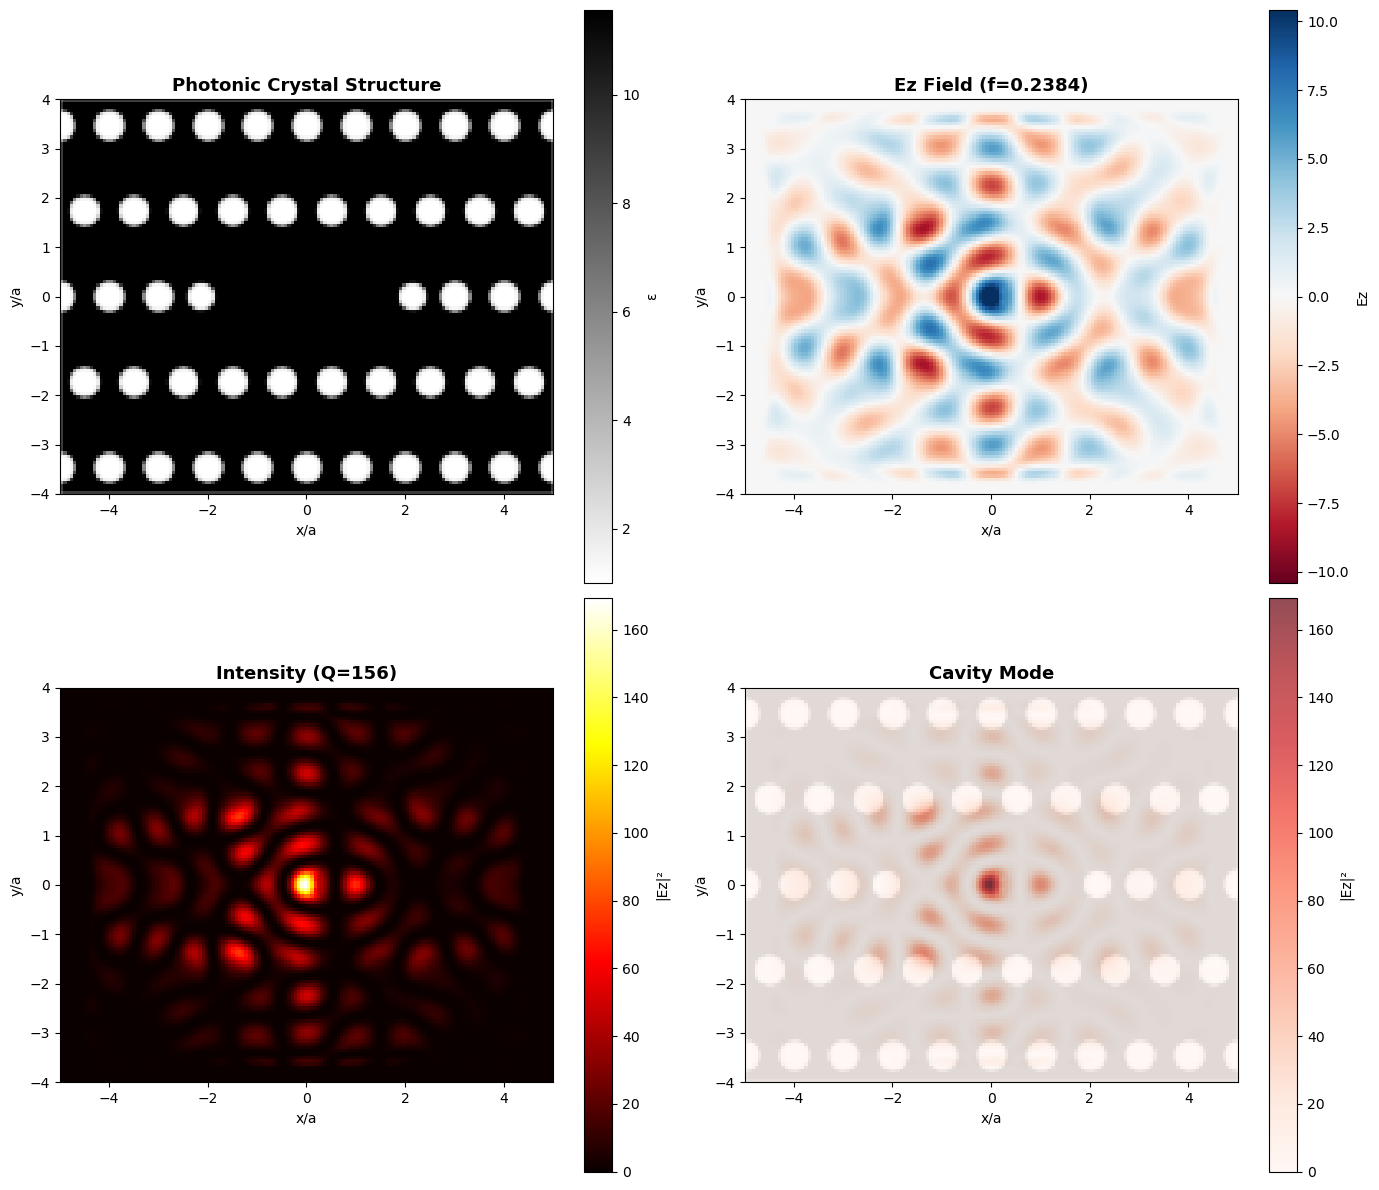

✓ Saved: l3_result.png


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
extent = [-sx/2, sx/2, -sy/2, sy/2]

# 1. Structure
im1 = axes[0,0].imshow(eps.T, extent=extent, cmap='gray_r', origin='lower')
axes[0,0].set_title('Photonic Crystal Structure', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('x/a')
axes[0,0].set_ylabel('y/a')
axes[0,0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0,0], label='ε')

# 2. Ez field
vmax = np.abs(np.real(ez)).max() * 0.8
im2 = axes[0,1].imshow(np.real(ez).T, extent=extent, cmap='RdBu',
                       origin='lower', vmin=-vmax, vmax=vmax)
axes[0,1].set_title(f'Ez Field (f={f_res:.4f})', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('x/a')
axes[0,1].set_ylabel('y/a')
axes[0,1].set_aspect('equal')
plt.colorbar(im2, ax=axes[0,1], label='Ez')

# 3. Intensity
im3 = axes[1,0].imshow(intensity.T, extent=extent, cmap='hot', origin='lower')
axes[1,0].set_title(f'Intensity (Q={Q:.0f})', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('x/a')
axes[1,0].set_ylabel('y/a')
axes[1,0].set_aspect('equal')
plt.colorbar(im3, ax=axes[1,0], label='|Ez|²')

# 4. Overlay
axes[1,1].imshow(eps.T, extent=extent, cmap='gray_r', origin='lower', alpha=0.4)
im4 = axes[1,1].imshow(intensity.T, extent=extent, cmap='Reds', origin='lower', alpha=0.7)
axes[1,1].set_title('Cavity Mode', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('x/a')
axes[1,1].set_ylabel('y/a')
axes[1,1].set_aspect('equal')
plt.colorbar(im4, ax=axes[1,1], label='|Ez|²')

plt.tight_layout()
plt.savefig('l3_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: l3_result.png")

## Summary

In [55]:
print("="*60)
print("SUMMARY")
print("="*60)
print(f"Resonant frequency: f = {f_res:.6f}")
print(f"Wavelength: λ/a = {1/f_res:.4f}")
print(f"Q-factor: Q = {Q:.0f}")
print(f"\nFor a=240nm: λ ≈ {240/f_res:.0f} nm")
print(f"Peak intensity: {intensity.max():.2e}")

if Q > 500:
    print("\n✓ Good result! Mode well confined.")
elif Q > 100:
    print("\n✓ Acceptable. Increase resolution for better Q.")
else:
    print("\n⚠ Low Q. See troubleshooting below.")
print("="*60)

SUMMARY
Resonant frequency: f = 0.238443
Wavelength: λ/a = 4.1939
Q-factor: Q = 156

For a=240nm: λ ≈ 1007 nm
Peak intensity: 1.69e+02

✓ Acceptable. Increase resolution for better Q.


## Troubleshooting

### If Q is negative or very low (<100):
1. **Adjust frequency**: `fcen = 0.30` (try 0.25-0.32)
2. **Widen search**: `df = 0.35`
3. **Smaller holes**: `r = 0.27 * a`
4. **Higher resolution**: `resolution = 18`

### If fields only at edges:
- Source position fixed above (0.2a, 0.1a)
- Try: `center=mp.Vector3(0, 0.15*a, 0)`

### Best parameter ranges:
```python
resolution = 15-20    # Sweet spot
runtime = 150-250     # Good convergence
r = 0.27-0.29        # Not too large
fcen = 0.27-0.31     # Search different centers
df = 0.25-0.35       # Wide range
```

### For publication quality:
Use the full notebook with:
- `resolution = 30-40`
- `runtime = 400-600`
- Expected Q > 5000